# Предсказание предпочтения смартфона методом k ближайших соседей

Цель работы - оценка связи ответов анкеты с предпочитаемой платформой смартфона

In [1]:
# Подключаем библиотеки для загрузки, чистки, обучения и оценки модели
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.utils.validation import check_is_fitted

## Данные и признаки

Целевая переменная задаётся по названию вопроса. Временная отметка исключена: она описывает порядок заполнения, а не характеристику респондента. Перед подготовкой признаков проверяются пропуски и баланс классов.


In [2]:
def find_column(columns, *needles: str) -> str:
    """Находит колонку по фрагментам названия, игнорируя лишние пробелы."""
    for column in columns:
        compact = re.sub(r"\s+", " ", column).strip().lower()
        if all(needle.lower() in compact for needle in needles):
            return column
    raise KeyError(f"Не найдена колонка с фрагментами: {needles}")


# Загружаем ответы анкеты
data_candidates = [
    Path("practice_1/Предпочтение пользователей Iphone или android.csv"),
    Path("Предпочтение пользователей Iphone или android.csv"),
    Path("practice_1/data_utf8.xlsx"),
    Path("data_utf8.xlsx"),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Не найден файл анкеты в practice_1")

if data_path.suffix.lower() == ".csv":
    data = pd.read_csv(data_path)
else:
    data = pd.read_excel(data_path)

target_column = find_column(data.columns, "айфон", "андроид")
time_column = find_column(data.columns, "отметка времени")

print(f"Файл: {data_path}")
# Показываем размер набора и число ответов каждого класса
print(f"Размер выборки: {data.shape[0]} наблюдений, {data.shape[1]} столбца")
print("\nБаланс классов:")
display(data[target_column].value_counts().rename_axis(target_column).to_frame("Число наблюдений"))
print("\nПропуски по столбцам:")
display(data.isna().sum().to_frame("Пропуски").query("Пропуски > 0"))
print(f"Всего пропусков: {int(data.isna().sum().sum())}")

Файл: Предпочтение пользователей Iphone или android.csv
Размер выборки: 41 наблюдений, 23 столбца

Баланс классов:


,Число наблюдений
22. У Вас айфон или андроид?,
Андроид,22
Айфон,19



Пропуски по столбцам:


,Пропуски


Всего пропусков: 0


## Подготовка данных

В текстовых ответах удаляются лишние пробелы, бюджет приводится к рублям, близкие названия сфер деятельности объединяются. Исключаются анкеты с возрастом вне диапазона 16–80 лет, бюджетом вне диапазона 5000–500000 рублей или числом вместо сферы деятельности.


In [3]:
class MultiHotEncoder(BaseEstimator, TransformerMixin):
    """Кодирует ответы, разделённые точкой с запятой, в набор бинарных признаков."""

    def __init__(self, separator: str = ";", ignore_tokens: tuple[str, ...] = ()) -> None:
        self.separator = separator
        self.ignore_tokens = ignore_tokens

    def fit(self, X, y=None):
        ignore = {token.strip() for token in self.ignore_tokens}
        categories = sorted(
            {
                token
                for value in self._as_series(X)
                for token in self._split(value)
                if token not in ignore
            }
        )
        self.categories_ = np.asarray(categories, dtype=object)
        self._category_to_index = {
            category: index for index, category in enumerate(self.categories_)
        }
        return self

    def transform(self, X):
        check_is_fitted(self, ["categories_", "_category_to_index"])
        ignore = {token.strip() for token in self.ignore_tokens}
        values = self._as_series(X)
        encoded = np.zeros((len(values), len(self.categories_)), dtype=np.float64)
        for row_index, value in enumerate(values):
            for token in self._split(value):
                if token in ignore:
                    continue
                category_index = self._category_to_index.get(token)
                if category_index is not None:
                    encoded[row_index, category_index] = 1.0
        return encoded

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["categories_"])
        feature_name = "feature" if input_features is None else input_features[0]
        return np.asarray(
            [f"{feature_name}__{category}" for category in self.categories_],
            dtype=object,
        )

    @staticmethod
    def _as_series(X) -> pd.Series:
        if isinstance(X, pd.DataFrame):
            if X.shape[1] != 1:
                raise ValueError("MultiHotEncoder ожидает ровно одну колонку")
            return X.iloc[:, 0]
        if isinstance(X, pd.Series):
            return X
        values = np.asarray(X, dtype=object)
        if values.ndim == 2:
            if values.shape[1] != 1:
                raise ValueError("MultiHotEncoder ожидает ровно одну колонку")
            values = values[:, 0]
        return pd.Series(values)

    def _split(self, value) -> set[str]:
        if value is None or pd.isna(value):
            return set()
        return {
            token.strip()
            for token in str(value).split(self.separator)
            if token.strip()
        }


def normalize_text(value):
    """Убирает лишние пробелы, не трогая пропуски."""
    if value is None or pd.isna(value):
        return value
    return re.sub(r"\s+", " ", str(value)).strip()


def parse_budget(value):
    """Приводит бюджет к рублям: 100.000 -> 100000, 70 -> 70000."""
    if value is None or pd.isna(value):
        return np.nan
    text = str(value).strip().replace("\xa0", "").replace(" ", "")
    if re.fullmatch(r"\d{1,3}[.,]\d{3}", text):
        return float(text.replace(".", "").replace(",", ""))
    number = pd.to_numeric(text.replace(",", "."), errors="coerce")
    if pd.isna(number):
        return np.nan
    if 0 < number < 1000:
        return float(number * 1000)
    return float(number)


def normalize_occupation(value) -> str:
    """Объединяет близкие названия сфер деятельности."""
    text = str(normalize_text(value) or "").lower().replace("ё", "е")
    if not text or text.isdigit():
        return "Другое"
    if any(token in text for token in ("it", "ит", "программ", "разработ", "инженер", "тех под", "корпоратив")):
        return "IT"
    if "студент" in text:
        return "Студент"
    if "дизайн" in text:
        return "Дизайн"
    if text in {"продажи", "менеджер", "медиа"}:
        return "Продажи и менеджмент"
    if text in {"бизнес", "предприниматель"}:
        return "Бизнес"
    return "Другое"

In [4]:
age_column = find_column(data.columns, "лет")
budget_column = find_column(data.columns, "потратить")
occupation_column = find_column(data.columns, "сфера")
multi_select_column = find_column(data.columns, "переплатить")
change_years_column = find_column(data.columns, "меняете телефон")

# Убираем лишние пробелы и приводим числовые ответы к единому виду
cleaned = data.copy()
for column in cleaned.columns:
    if cleaned[column].dtype == object:
        cleaned[column] = cleaned[column].map(normalize_text)

budget_before = pd.to_numeric(data[budget_column], errors="coerce")
cleaned[budget_column] = cleaned[budget_column].map(parse_budget)
cleaned[age_column] = pd.to_numeric(cleaned[age_column], errors="coerce")
cleaned[change_years_column] = pd.to_numeric(cleaned[change_years_column], errors="coerce")
occupation_raw = cleaned[occupation_column]
cleaned[occupation_column] = occupation_raw.map(normalize_occupation)

# Исключаем анкеты с некорректными ответами
invalid_mask = (
    cleaned[age_column].lt(16)
    | cleaned[age_column].gt(80)
    | cleaned[budget_column].lt(5000)
    | cleaned[budget_column].gt(500000)
    | occupation_raw.astype(str).str.fullmatch(r"\d+", na=False)
)
removed = data.loc[invalid_mask, [age_column, budget_column, occupation_column, target_column]].copy()
removed.insert(0, "Исходный индекс", removed.index)

print("Удалённые невалидные анкеты:")
display(removed.reset_index(drop=True))

cleaned = cleaned.loc[~invalid_mask].reset_index(drop=True)

budget_compare = pd.DataFrame(
    {
        "Бюджет до чистки": budget_before.loc[~invalid_mask].reset_index(drop=True),
        "Бюджет после чистки": cleaned[budget_column],
    }
)
changed_budget = budget_compare[
    budget_compare["Бюджет до чистки"] != budget_compare["Бюджет после чистки"]
]
print("Бюджеты, которые изменились после разбора формата:")
display(changed_budget)
print("\nСфера деятельности после объединения синонимов:")
display(cleaned[occupation_column].value_counts().rename_axis("Сфера").to_frame("Число наблюдений"))
print(f"\nРазмер после чистки: {cleaned.shape[0]} наблюдений")
print("\nБаланс классов после чистки:")
display(cleaned[target_column].value_counts().rename_axis(target_column).to_frame("Число наблюдений"))

Удалённые невалидные анкеты:


,Исходный индекс,7.Сколько Вам лет?,8. Сколько в среднем вы готовы потратить на новый телефон?,15. Ваша сфера деятельности?,22. У Вас айфон или андроид?
0,40,5,3.0,5,Андроид


Бюджеты, которые изменились после разбора формата:


,Бюджет до чистки,Бюджет после чистки
2,60.0,60000.0
16,100.0,100000.0
21,90.0,90000.0
27,70.0,70000.0
30,60.0,60000.0
31,120.0,120000.0



Сфера деятельности после объединения синонимов:


,Число наблюдений
Сфера,
IT,25
Студент,4
Другое,4
Продажи и менеджмент,3
Дизайн,2
Бизнес,2



Размер после чистки: 40 наблюдений

Баланс классов после чистки:


,Число наблюдений
22. У Вас айфон или андроид?,
Андроид,21
Айфон,19


## Кодирование признаков

Числовые ответы масштабируются в диапазон `[0, 1]`. Упорядоченные ответы кодируются с сохранением порядка и также масштабируются. Бинарные категории представлены одним признаком, остальные — отдельными колонками. Вопрос 4 обрабатывается как multi-hot признак: каждый выбранный вариант получает отдельную бинарную колонку.


In [5]:
# Отделяем ответы для прогноза и убираем временную отметку
y = cleaned[target_column]
X = cleaned.drop(columns=[target_column, time_column]).copy()

# Выделяем числовые, упорядоченные и категориальные ответы
numeric_features = [
    find_column(X.columns, "лет"),
    find_column(X.columns, "потратить"),
    find_column(X.columns, "кастомизации"),
    find_column(X.columns, "меняете телефон"),
    find_column(X.columns, "заряжаете"),
    find_column(X.columns, "яблоки"),
]
for column in numeric_features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

ordinal_features = [
    find_column(X.columns, "фотографируете"),
    find_column(X.columns, "перепродаже"),
    find_column(X.columns, "актуальность"),
]
ordinal_categories = [
    ["Раз в месяц", "Раз в неделю", "Каждый день"],
    ["Плохо", "Хорошо"],
    ["Не важна", "Важна"],
]

categorical_features = [
    column
    for column in X.columns
    if column not in numeric_features + ordinal_features + [multi_select_column]
]

feature_groups = pd.DataFrame(
    {
        "Группа": (
            ["числовой"] * len(numeric_features)
            + ["порядковый"] * len(ordinal_features)
            + ["множественный выбор"]
            + ["категориальный"] * len(categorical_features)
        ),
        "Признак": numeric_features + ordinal_features + [multi_select_column] + categorical_features,
    }
)
display(feature_groups)
print(f"Пропуски в признаках после чистки: {int(X.isna().sum().sum())}")

,Группа,Признак
0,числовой,7.Сколько Вам лет?
1,числовой,8. Сколько в среднем вы готовы потратить на но...
2,числовой,9. Насколько вам важна возможность кастомизаци...
3,числовой,13. Как часто вы меняете телефон? В годах.
4,числовой,18. Сколько раз в день вы примерно заряжаете т...
5,числовой,21. Как часто вы кушаете яблоки от 1 до 10?
6,порядковый,2. Часто ли вы фотографируете?
7,порядковый,11.Как вы относитесь к перепродаже своего смар...
8,порядковый,14. Насколько важна актуальность и обслуживани...
9,множественный выбор,"4. За что вы готовы переплатить, покупая смарт..."


Пропуски в признаках после чистки: 0


## Подготовка модели

Масштабирование и кодирование выполняются внутри конвейера. Параметры преобразований и словари категорий оцениваются только на обучающих фолдах.


In [6]:
# Готовим преобразования для каждой группы признаков
preprocessor = ColumnTransformer(
    [
        ("numeric", MinMaxScaler(), numeric_features),
        (
            "ordinal",
            Pipeline(
                [
                    (
                        "encode",
                        OrdinalEncoder(
                            categories=ordinal_categories,
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                    ("scale", MinMaxScaler()),
                ]
            ),
            ordinal_features,
        ),
        (
            "multi_select",
            MultiHotEncoder(ignore_tokens=("Мультивыбор",)),
            [multi_select_column],
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", drop="if_binary"),
            categorical_features,
        ),
    ],
    sparse_threshold=0,
)

# Проверка раздельного кодирования множественных ответов
test_answers = pd.DataFrame({"q4": ["Экосистема;Надежность", "Экосистема;Камера;Надежность;Мультивыбор"]})
test_encoder = MultiHotEncoder(ignore_tokens=("Мультивыбор",)).fit(test_answers)
test_feature_names = test_encoder.get_feature_names_out(["q4"]).tolist()

assert test_feature_names == ["q4__Камера", "q4__Надежность", "q4__Экосистема"]
assert test_encoder.transform(test_answers).tolist() == [[0.0, 1.0, 1.0], [1.0, 1.0, 1.0]]
assert "Мультивыбор" not in "".join(test_feature_names)
assert multi_select_column not in categorical_features
print("Проверка multi-hot кодирования пройдена")

Проверка multi-hot кодирования пройдена


## Подбор модели

Данные делятся на обучающую и тестовую части стратифицированно в пропорции 80/20. Число соседей `k` из набора 3, 5, 7, 9, веса соседей и метрика расстояния подбираются по сбалансированной точности в пятикратной стратифицированной кросс-валидации.

Рассматриваются варианты со средней оценкой не ниже лучшей более чем на одно стандартное отклонение оценок лучшего варианта по фолдам. Среди них выбирается большее `k`, затем равномерные веса, затем более высокая средняя оценка. 


In [7]:
# Делим данные на части для обучения и итоговой проверки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Обучающая выборка:", dict(y_train.value_counts()))
print("Отложенная выборка:", dict(y_test.value_counts()))

# Собираем подготовку данных и модель в одну последовательность
pipeline = Pipeline(
    [("preprocessor", preprocessor), ("model", KNeighborsClassifier(algorithm="ball_tree"))]
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Задаём варианты числа соседей, весов и расстояния для проверки
search = GridSearchCV(
    pipeline,
    param_grid={
        "model__n_neighbors": [3, 5, 7, 9],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"],
    },
    scoring="balanced_accuracy",
    cv=cv,
    refit=False,
    error_score="raise",
)
# Обучаем перебор и сравниваем варианты
search.fit(X_train, y_train)

# Собираем таблицу оценок для каждого набора параметров
cv_table = (
    pd.DataFrame(search.cv_results_)[
        [
            "param_model__n_neighbors",
            "param_model__weights",
            "param_model__metric",
            "mean_test_score",
            "std_test_score",
        ]
    ]
    .rename(
        columns={
            "param_model__n_neighbors": "k",
            "param_model__weights": "weights",
            "param_model__metric": "metric",
            "mean_test_score": "balanced_accuracy_mean",
            "std_test_score": "balanced_accuracy_std",
        }
    )
    .astype({"k": int})
    .sort_values(["balanced_accuracy_mean", "k"], ascending=[False, False])
    .reset_index(drop=True)
)

# Среди близких по качеству вариантов выбираем большее число соседей
best_mean = cv_table["balanced_accuracy_mean"].max()
best_std = cv_table.loc[cv_table["balanced_accuracy_mean"].idxmax(), "balanced_accuracy_std"]
candidates = cv_table[cv_table["balanced_accuracy_mean"] >= best_mean - best_std].copy()
candidates["is_uniform"] = (candidates["weights"] == "uniform").astype(int)
chosen = candidates.sort_values(
    ["k", "is_uniform", "balanced_accuracy_mean"],
    ascending=[False, False, False],
).iloc[0]

best_k = int(chosen["k"])
best_weights = str(chosen["weights"])
best_metric = str(chosen["metric"])

display(cv_table)
print(
    f"Выбрано: k={best_k}, weights={best_weights}, metric={best_metric} "
    f"(CV balanced accuracy = {chosen['balanced_accuracy_mean']:.3f} ± {chosen['balanced_accuracy_std']:.3f})"
)

Обучающая выборка: {'Андроид': np.int64(17), 'Айфон': np.int64(15)}
Отложенная выборка: {'Айфон': np.int64(4), 'Андроид': np.int64(4)}


,k,weights,metric,balanced_accuracy_mean,balanced_accuracy_std
0,5,uniform,euclidean,0.775000,0.157233
1,5,distance,euclidean,0.775000,0.157233
2,5,uniform,manhattan,0.775000,0.157233
3,5,distance,manhattan,0.775000,0.157233
4,7,distance,manhattan,0.750000,0.197203
5,9,uniform,euclidean,0.741667,0.158990
6,9,distance,euclidean,0.741667,0.158990
7,3,uniform,euclidean,0.741667,0.217945
8,3,distance,euclidean,0.741667,0.217945
9,7,uniform,euclidean,0.716667,0.194365


Выбрано: k=9, weights=uniform, metric=euclidean (CV balanced accuracy = 0.742 ± 0.159)


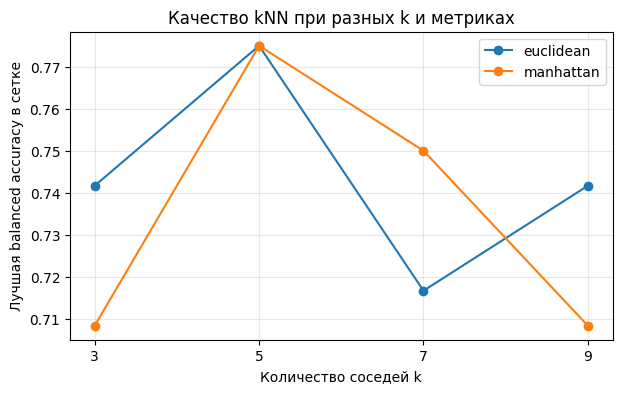

In [8]:
plot_table = (
    cv_table.groupby(["k", "metric"], as_index=False)
    .agg(balanced_accuracy_mean=("balanced_accuracy_mean", "max"))
    .sort_values("k")
)

plt.figure(figsize=(7, 4))
for metric, group in plot_table.groupby("metric"):
    plt.plot(group["k"], group["balanced_accuracy_mean"], marker="o", label=metric)
plt.xlabel("Количество соседей k")
plt.ylabel("Лучшая balanced accuracy в сетке")
plt.title("Качество kNN при разных k и метриках")
plt.xticks(sorted(plot_table["k"].unique()))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Проверка на тестовой выборке

Выбранная модель обучается только на обучающей части с найденными параметрами. Тестовая выборка не используется в подборе. Результаты сравниваются с классификатором, который всегда предсказывает наиболее частый класс обучающей выборки.


Число признаков после кодирования: 33


,kNN,Константа (частый класс)
accuracy_test,0.875000,0.500000
balanced_accuracy_test,0.875000,0.500000
macro_f1_test,0.873016,0.333333
balanced_accuracy_cv,0.741667,0.500000


Классификационный отчёт kNN:

              precision    recall  f1-score   support

       Айфон       1.00      0.75      0.86         4
     Андроид       0.80      1.00      0.89         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



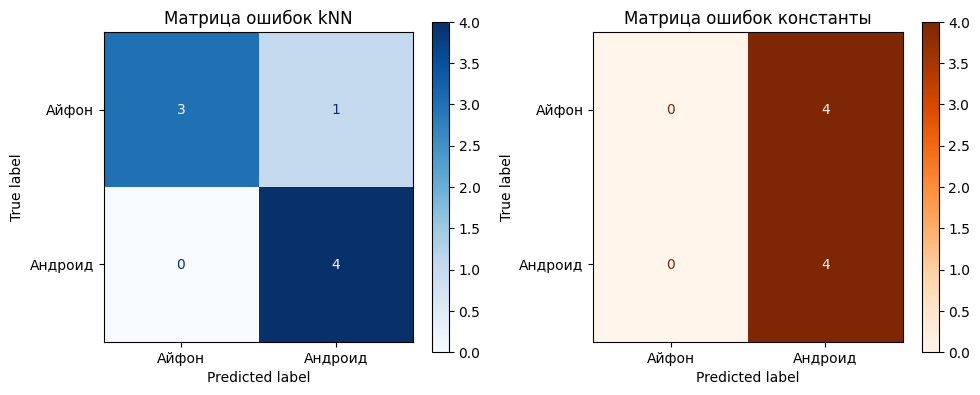

In [9]:
# Обучаем итоговую модель с выбранными параметрами
model = pipeline.set_params(
    model__n_neighbors=best_k,
    model__weights=best_weights,
    model__metric=best_metric,
).fit(X_train, y_train)

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
print(f"Число признаков после кодирования: {len(feature_names)}")

# Получаем прогнозы для отложенной части данных
y_pred = model.predict(X_test)

# Проверяем результат относительно самого частого класса
dummy = DummyClassifier(strategy="most_frequent")
dummy_cv = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="balanced_accuracy")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

# Считаем общую и поклассовую точность на отложенных данных
metrics = pd.DataFrame(
    {
        "kNN": [
            accuracy_score(y_test, y_pred),
            balanced_accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro"),
            float(chosen["balanced_accuracy_mean"]),
        ],
        "Константа (частый класс)": [
            accuracy_score(y_test, dummy_pred),
            balanced_accuracy_score(y_test, dummy_pred),
            f1_score(y_test, dummy_pred, average="macro"),
            float(dummy_cv.mean()),
        ],
    },
    index=["accuracy_test", "balanced_accuracy_test", "macro_f1_test", "balanced_accuracy_cv"],
)
display(metrics)
print("Классификационный отчёт kNN:\n")
print(classification_report(y_test, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Матрица ошибок kNN")
ConfusionMatrixDisplay.from_predictions(y_test, dummy_pred, cmap="Oranges", ax=axes[1])
axes[1].set_title("Матрица ошибок константы")
plt.tight_layout()
plt.show()

In [10]:
prediction_table = pd.DataFrame({
    "Факт": y_test,
    "Прогноз": y_pred,
})

prediction_table["Верно"] = (
    prediction_table["Факт"] == prediction_table["Прогноз"]
)

display(prediction_table)

,Факт,Прогноз,Верно
13,Айфон,Айфон,True
31,Айфон,Айфон,True
33,Андроид,Андроид,True
22,Андроид,Андроид,True
10,Айфон,Айфон,True
4,Андроид,Андроид,True
21,Айфон,Андроид,False
0,Андроид,Андроид,True


## Вывод и источники

Выбрано значение `k`, дающее наибольшую среднюю сбалансированную точность; при одинаковой оценке предпочтение получает меньшее `k`. При `n=41` оценка имеет высокую неопределённость и чувствительна к конкретному разбиению

## Какая информация взята из статей

### Wu et al. (2021), [«Predicting Chemical Hazard across Taxa through Machine Learning»](https://arxiv.org/abs/2110.03688)

Авторы добавили к главным химическим свойствам контекст — сведения о виде рыб и условиях эксперимента. Они обрабатывали числовые, бинарные и категориальные блоки признаков раздельно: применяли евклидово расстояние к числовым признакам, расстояние Хэмминга к бинарным и категориальным признакам, нормировали расстояния и подбирали веса блоков по кросс-валидации. При объединении информации в их задаче 3-NN достиг accuracy 0.918 и F1 0.890, а модель только с химическими признаками — accuracy 0.841 и F1 0.530

**Перевод фрагмента статьи:**

> «Поскольку наши данные явно разделены на три источника информации, мы можем настроить модели так, чтобы добиться более высокой эффективности»
>
> «Разделение признаков на более мелкие группы может дополнительно повысить эффективность, но потребует более длительного подбора гиперпараметров»

**Что применено в этой работе.** Применён НЕ их специализированный расчёт расстояния, а тот же принцип: числовые ответы масштабируются `RobustScaler`, обычные категориальные ответы кодируются `OneHotEncoder`, а множественные ответы вопроса 4 разбираются `MultiHotEncoder` на отдельные 0/1-признаки. Используются все содержательные вопросы анкеты; временная отметка исключается, поскольку фиксирует время заполнения
